# PLINK vs. GERMLINE: IBD-Based Relatedness Detection
## CSE 284 | Dhaivat Pachchigar, Harsh Sharma, Sharanya Ranka

This notebook compares two IBD detection tools on the LWK chr22 dataset:
- **PLINK `--genome`**: Computes genome-wide PI_HAT (proportion IBD) for all pairs
- **GERMLINE**: Detects specific long shared haplotype segments

All data is read from `~/ibd_project/data/`.

---
## 0. Setup & Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import networkx as nx
import os
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = os.path.expanduser('~/ibd_project/data')
PLINK_FILE = os.path.join(DATA_DIR, 'lwk_plink_ibd.genome')
GERMLINE_FILE = os.path.join(DATA_DIR, 'lwk_germline_final.match')

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})
sns.set_palette('tab10')

CHR22_CM_LENGTH = 74.11  # we found it from notebook

print('Setup complete.')
print(f'PLINK file exists: {os.path.exists(PLINK_FILE)}')
print(f'GERMLINE file exists: {os.path.exists(GERMLINE_FILE)}')

Setup complete.
PLINK file exists: True
GERMLINE file exists: True


---
## 1. Load Data

In [25]:
plink = pd.read_csv(PLINK_FILE, sep=r'\s+', engine='python')

plink_flagged = plink[plink['PI_HAT'] >= 0.05].copy()

print(f'PLINK total pairs: {len(plink):,}')
print(f'PLINK flagged pairs with pi hat >= 0.05: {len(plink_flagged):,}')
print()
plink_flagged.head(10)

PLINK total pairs: 1,085
PLINK flagged pairs with pi hat >= 0.05: 1,085



,FID1,IID1,FID2,IID2,RT,EZ,Z0,Z1,Z2,PI_HAT,PHE,DST,PPC,RATIO
0,NA19020,NA19020,NA19035,NA19035,UN,NaN,0.8822,0.1178,0.0000,0.0589,-1,0.756377,0.5361,2.0500
1,NA19020,NA19020,NA19041,NA19041,UN,NaN,0.8424,0.1576,0.0000,0.0788,-1,0.748868,0.6448,2.2222
2,NA19020,NA19020,NA19308,NA19308,UN,NaN,0.8802,0.1104,0.0094,0.0646,-1,0.766865,0.7081,2.3333
3,NA19020,NA19020,NA19318,NA19318,UN,NaN,0.7807,0.2193,0.0000,0.1096,-1,0.765197,0.7943,2.5294
4,NA19020,NA19020,NA19324,NA19324,UN,NaN,0.8879,0.1121,0.0000,0.0560,-1,0.759476,0.3921,1.8571
5,NA19020,NA19020,NA19338,NA19338,UN,NaN,0.8675,0.1325,0.0000,0.0663,-1,0.755781,0.9071,3.0000
6,NA19020,NA19020,NA19346,NA19346,UN,NaN,0.8536,0.1464,0.0000,0.0732,-1,0.758522,0.9724,3.6154
7,NA19020,NA19020,NA19347,NA19347,UN,NaN,0.8996,0.1004,0.0000,0.0502,-1,0.761502,0.1786,1.5652
8,NA19020,NA19020,NA19352,NA19352,UN,NaN,0.8403,0.1597,0.0000,0.0798,-1,0.758164,0.3921,1.8571
9,NA19020,NA19020,NA19355,NA19355,UN,NaN,0.8176,0.1824,0.0000,0.0912,-1,0.755900,0.9498,3.2857


In [26]:
print(germline.columns.tolist())
print(germline.head())

['FID1', 'IID1', 'FID2', 'IID2', 'Chr', 'Start_bp', 'End_bp', 'Start_SNP', 'End_SNP', 'Num_SNPs', 'Length', 'Unit', 'Mismatches', 'Col14', 'Col15', 'pct_ibd', 'pair']
      FID1     IID1     FID2     IID2  Chr  Start_bp    End_bp  Start_SNP  \
0  NA19396  NA19396  NA19397  NA19397   22  21024880  23836819   rs520698   
1  NA19347  NA19347  NA19352  NA19352   22  36649966  44539902  rs6000220   
2  NA19331  NA19331  NA19334  NA19334   22  16504399  47292488  rs4911642   
3  NA19434  NA19434  NA19444  NA19444   22  38115556  48200592   rs739140   
4  NA19373  NA19373  NA19374  NA19374   22  46196881  50181915   rs136012   

     End_SNP  Num_SNPs  Length Unit  Mismatches  Col14  Col15     pct_ibd  \
0   rs140157       258   6.798   cM           0      0      0   11.522034   
1  rs2284158       770  11.074   cM           0      0      0   18.769492   
2   rs738932      3456  59.413   cM           0      0      0  100.700000   
3  rs9615222      1152  16.811   cM           0      0      0 

In [27]:
germline_cols = [
    'FID1','IID1','FID2','IID2','Chr',
    'Start_bp','End_bp','Start_SNP','End_SNP',
    'Num_SNPs','Length','Unit','Mismatches',
    'Col14','Col15'
]
germline = pd.read_csv(GERMLINE_FILE, sep=r'\s+', header=None,
                       names=germline_cols, engine='python')
germline['pct_ibd'] = germline['Length'] / CHR22_CM_LENGTH * 100

# used llm to get the pairs
germline['pair'] = germline.apply(
    lambda r: tuple(sorted([r['IID1'], r['IID2']])), axis=1
)

# used llm for formatting in print cells
print(f'GERMLINE total segments: {len(germline)}')
print(f'Unique pairs: {germline["pair"].nunique()}')
print()
germline[['IID1','IID2','Length','Unit','pct_ibd','Num_SNPs']].head(10)

GERMLINE total segments: 5
Unique pairs: 5



,IID1,IID2,Length,Unit,pct_ibd,Num_SNPs
0,NA19396,NA19397,6.798,cM,9.172851,258
1,NA19347,NA19352,11.074,cM,14.942653,770
2,NA19331,NA19334,59.413,cM,80.168668,3456
3,NA19434,NA19444,16.811,cM,22.683848,1152
4,NA19373,NA19374,14.051,cM,18.959655,800


In [28]:
def bin_relationship(pi_hat):
    if pi_hat >= 0.5:
        return 'Full Siblings / Twins'
    elif pi_hat >= 0.25:
        return 'Half Siblings / Grandparent'
    elif pi_hat >= 0.125:
        return 'First Cousins'
    else:
        return 'Distant / Unrelated'

plink_flagged['relationship'] = plink_flagged['PI_HAT'].apply(bin_relationship)

# Canonical pair key for PLINK
plink_flagged['pair'] = plink_flagged.apply(
    lambda r: tuple(sorted([r['IID1'], r['IID2']])), axis=1
)

print('Relationship bin counts (PI_HAT >= 0.05):')
print(plink_flagged['relationship'].value_counts())

Relationship bin counts (PI_HAT >= 0.05):
Distant / Unrelated            1033
First Cousins                    32
Half Siblings / Grandparent      15
Full Siblings / Twins             5
Name: relationship, dtype: int64


---
## 2. PLINK Analysis

### Chart 1: PI_HAT Distribution Histogram

so now, we will show which pairs falls into which category to find their relatedness

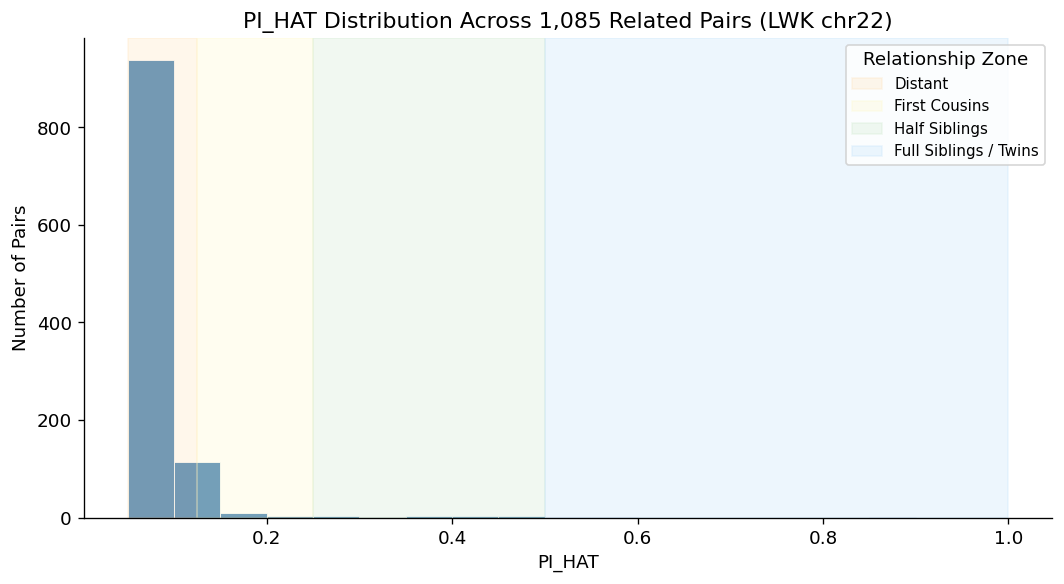


Relationship bin summary:
Distant / Unrelated            1033
First Cousins                    32
Half Siblings / Grandparent      15
Full Siblings / Twins             5


In [29]:
# llm was used for formatting but the idea of creating this graph was suggested by the ta
fig, ax = plt.subplots(figsize=(9, 5))

# Bin boundaries and colors
bins = np.arange(0.05, 1.05, 0.05)
n, edges, patches = ax.hist(plink_flagged['PI_HAT'], bins=bins,
                             color='steelblue', edgecolor='white', linewidth=0.5)

# Shade relationship zones
zones = [
    (0.05, 0.125, '#ffe0b2', 'Distant'),
    (0.125, 0.25,  '#fff9c4', 'First Cousins'),
    (0.25,  0.50,  '#c8e6c9', 'Half Siblings'),
    (0.50,  1.00,  '#bbdefb', 'Full Siblings / Twins'),
]
for xmin, xmax, color, label in zones:
    ax.axvspan(xmin, xmax, alpha=0.25, color=color, label=label)

ax.set_xlabel('PI_HAT')
ax.set_ylabel('Number of Pairs')
ax.set_title('PI_HAT Distribution Across 1,085 Related Pairs (LWK chr22)')
ax.legend(title='Relationship Zone', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig1_pihat_histogram.png'), dpi=150)
plt.show()

print('\nRelationship bin summary:')
print(plink_flagged['relationship'].value_counts().to_string())

### Chart 2: Z0/Z1/Z2 IBD Triangle Plot

Classic IBD triangle: plots Z0 (P(IBD=0)) vs Z1 (P(IBD=1)) for all flagged pairs, colored by PI_HAT. Clusters correspond to relationship types.

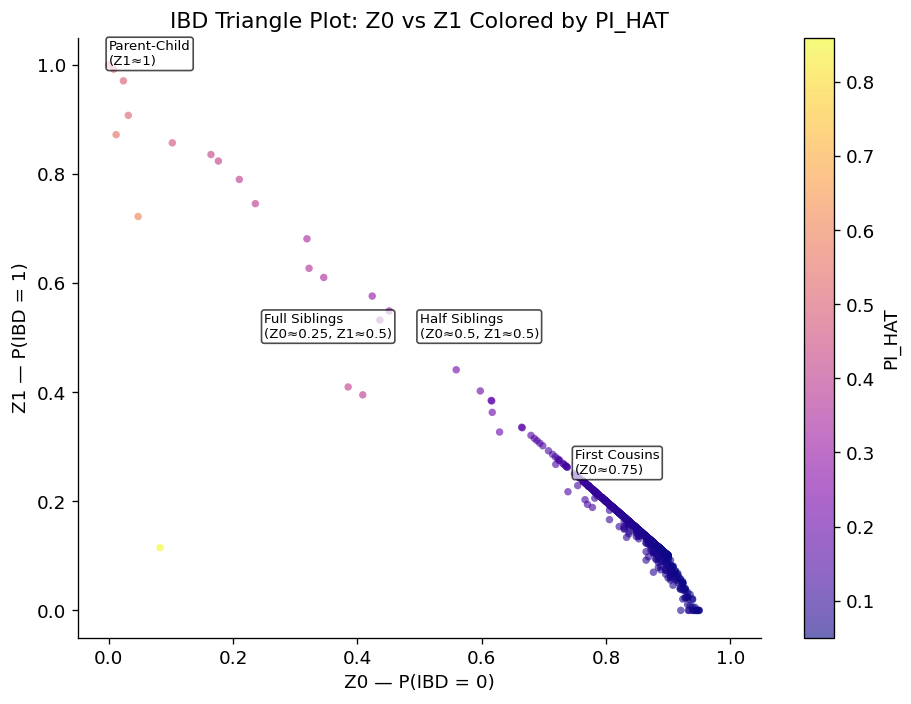

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    plink_flagged['Z0'], plink_flagged['Z1'],
    c=plink_flagged['PI_HAT'], cmap='plasma',
    alpha=0.6, s=20, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='PI_HAT')

# Annotate expected clusters
cluster_labels = [
    (0.0,  1.0,  'Parent-Child\n(Z1≈1)'),
    (0.25, 0.5,  'Full Siblings\n(Z0≈0.25, Z1≈0.5)'),
    (0.5,  0.5,  'Half Siblings\n(Z0≈0.5, Z1≈0.5)'),
    (0.75, 0.25, 'First Cousins\n(Z0≈0.75)'),
]
for x, y, label in cluster_labels:
    ax.annotate(label, xy=(x, y), fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_xlabel('Z0 — P(IBD = 0)')
ax.set_ylabel('Z1 — P(IBD = 1)')
ax.set_title('IBD Triangle Plot: Z0 vs Z1 Colored by PI_HAT')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig2_ibd_triangle.png'), dpi=150)
plt.show()

### Chart 3: Network / Cluster Graph

Nodes = individuals, edges = pairs with PI_HAT >= 0.2. Edge thickness and color scale with PI_HAT. Shows family-like clusters.

In [33]:
THRESHOLD = 0.2
high = plink_flagged[plink_flagged['PI_HAT'] >= THRESHOLD].copy()

G = nx.Graph()
for _, row in high.iterrows():
    G.add_edge(row['IID1'], row['IID2'], weight=row['PI_HAT'])

# Compute connected components (family clusters)
components = list(nx.connected_components(G))
print(f'Pairs with PI_HAT >= {THRESHOLD}: {len(high)}')
print(f'Individuals in graph: {G.number_of_nodes()}')
print(f'Connected components (family clusters): {len(components)}')
for i, comp in enumerate(sorted(components, key=len, reverse=True)):
    print(f'  Cluster {i+1} ({len(comp)} individuals): {", ".join(sorted(comp))}')


Pairs with PI_HAT >= 0.2: 24
Individuals in graph: 28
Connected components (family clusters): 9
  Cluster 1 (6 individuals): NA19307, NA19312, NA19360, NA19380, NA19381, NA19382
  Cluster 2 (4 individuals): NA19434, NA19444, NA19445, NA19453
  Cluster 3 (4 individuals): NA19438, NA19443, NA19469, NA19470
  Cluster 4 (3 individuals): NA19313, NA19331, NA19334
  Cluster 5 (3 individuals): NA19376, NA19396, NA19397
  Cluster 6 (2 individuals): NA19046, NA19321
  Cluster 7 (2 individuals): NA19347, NA19352
  Cluster 8 (2 individuals): NA19373, NA19374
  Cluster 9 (2 individuals): NA19451, NA19452


### Chart 4: PI_HAT vs Z1 Scatter

Helps separate parent-child pairs (Z1 ≈ 1.0) from sibling pairs (Z1 ≈ 0.5, high Z2).

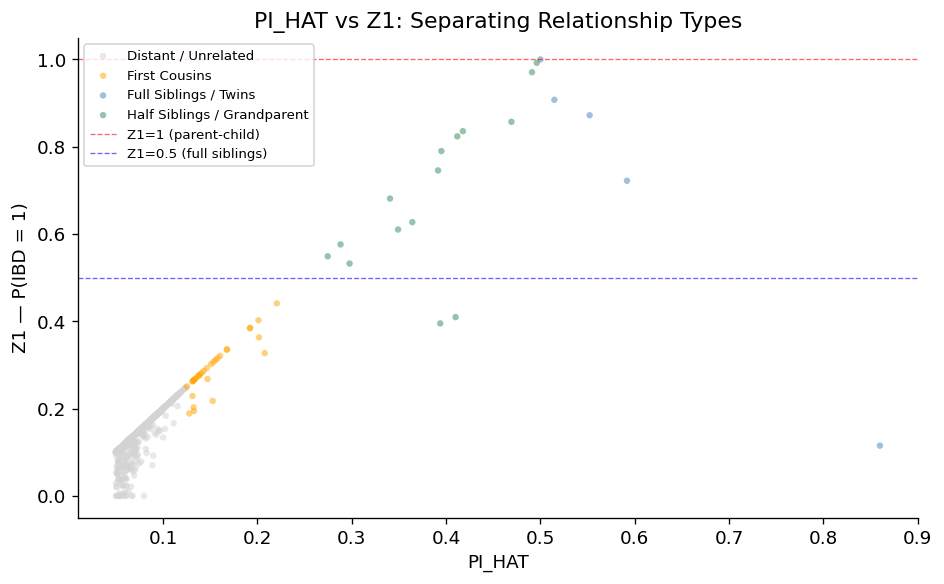

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))

rel_colors = {
    'Full Siblings / Twins':       'steelblue',
    'Half Siblings / Grandparent': 'seagreen',
    'First Cousins':               'orange',
    'Distant / Unrelated':         'lightgrey',
}
for rel, grp in plink_flagged.groupby('relationship'):
    ax.scatter(grp['PI_HAT'], grp['Z1'], label=rel,
               color=rel_colors[rel], alpha=0.5, s=15, edgecolors='none')

# Reference lines
ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Z1=1 (parent-child)')
ax.axhline(0.5, color='blue', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Z1=0.5 (full siblings)')

ax.set_xlabel('PI_HAT')
ax.set_ylabel('Z1 — P(IBD = 1)')
ax.set_title('PI_HAT vs Z1: Separating Relationship Types')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig4_pihat_z1.png'), dpi=150)
plt.show()

---
## 3. Cross-Tool Comparison

GERMLINE detected 5 IBD segments. We now merge these with PLINK output to compare metrics directly.

### Chart 5: PI_HAT vs % IBD Length (cM) Scatter

Core deliverable: for the 5 pairs detected by GERMLINE, how well does PI_HAT correlate with % of chr22 shared?

In [35]:
# Build GERMLINE per-pair summary
germline_pairs = germline.groupby('pair').agg(
    total_cM=('Length', 'sum'),
    num_segments=('Length', 'count')
).reset_index()
germline_pairs['pct_ibd'] = germline_pairs['total_cM'] / CHR22_CM_LENGTH * 100
germline_pairs['IID1'] = germline_pairs['pair'].apply(lambda x: x[0])
germline_pairs['IID2'] = germline_pairs['pair'].apply(lambda x: x[1])

# Merge with PLINK
merged = germline_pairs.merge(
    plink_flagged[['pair','PI_HAT','Z0','Z1','Z2','relationship']],
    on='pair', how='left'
)

print('Overlapping pairs (GERMLINE ∩ PLINK):')
print(merged[['IID1','IID2','PI_HAT','total_cM','pct_ibd','relationship']].to_string(index=False))

Overlapping pairs (GERMLINE ∩ PLINK):
   IID1    IID2  PI_HAT  total_cM   pct_ibd                relationship
NA19331 NA19334  0.8599    59.413 80.168668       Full Siblings / Twins
NA19347 NA19352  0.4101    11.074 14.942653 Half Siblings / Grandparent
NA19373 NA19374  0.3938    14.051 18.959655 Half Siblings / Grandparent
NA19396 NA19397  0.5522     6.798  9.172851       Full Siblings / Twins
NA19434 NA19444  0.5918    16.811 22.683848       Full Siblings / Twins


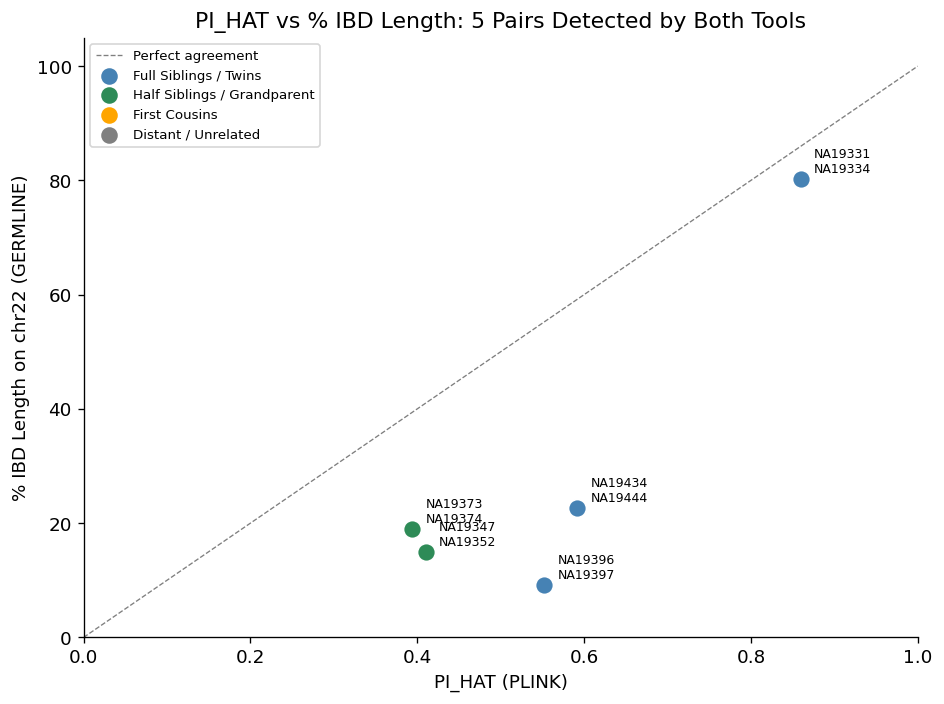

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

rel_colors = {
    'Full Siblings / Twins':       'steelblue',
    'Half Siblings / Grandparent': 'seagreen',
    'First Cousins':               'orange',
    'Distant / Unrelated':         'grey',
}

for _, row in merged.iterrows():
    color = rel_colors.get(row.get('relationship', ''), 'grey')
    ax.scatter(row['PI_HAT'], row['pct_ibd'], s=120, color=color,
               zorder=5, edgecolors='white', linewidth=1.2)
    pair_label = f"{row['IID1']}\n{row['IID2']}"
    ax.annotate(pair_label, (row['PI_HAT'], row['pct_ibd']),
                textcoords='offset points', xytext=(8, 4), fontsize=7.5)

# Reference line: perfect agreement (PI_HAT * 100 == % IBD)
x_ref = np.linspace(0, 1, 100)
ax.plot(x_ref, x_ref * 100, 'k--', linewidth=0.8, alpha=0.5, label='Perfect agreement')

for rel, color in rel_colors.items():
    ax.scatter([], [], color=color, label=rel, s=80)
ax.legend(fontsize=8, loc='upper left')

ax.set_xlabel('PI_HAT (PLINK)')
ax.set_ylabel('% IBD Length on chr22 (GERMLINE)')
ax.set_title('PI_HAT vs % IBD Length: 5 Pairs Detected by Both Tools')
ax.set_xlim(0, 1)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig5_pihat_vs_ibd.png'), dpi=150)
plt.show()

### Chart 6: Side-by-Side Bar Chart

For the 5 shared pairs, compare PI_HAT (PLINK) and normalized % IBD length (GERMLINE) side by side.

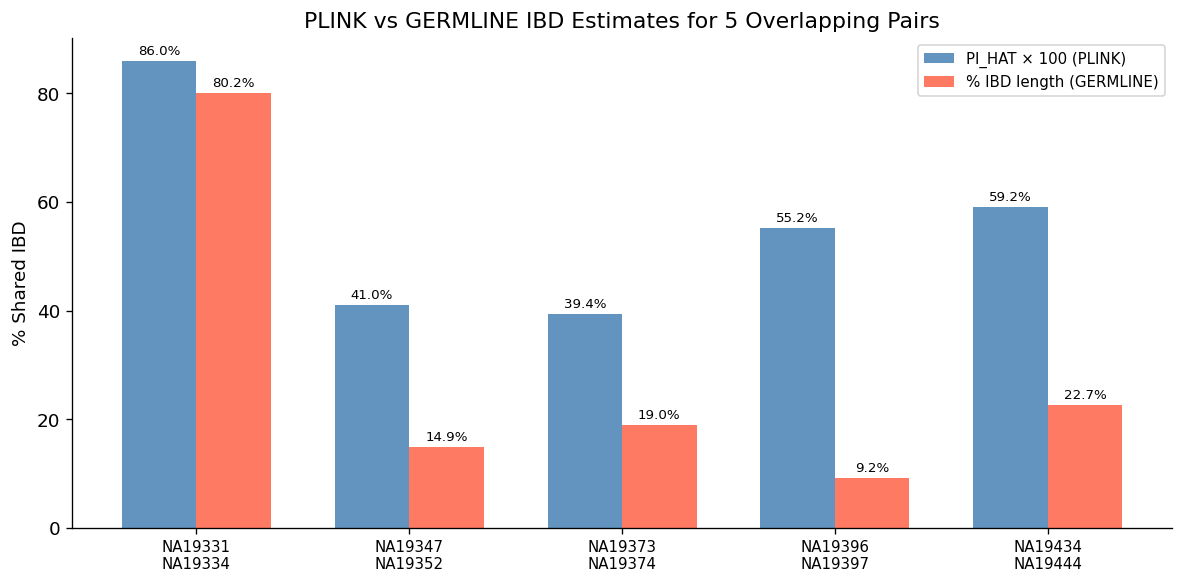

In [37]:
pair_labels = [f"{r['IID1']}\n{r['IID2']}" for _, r in merged.iterrows()]
x = np.arange(len(merged))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, merged['PI_HAT'] * 100,
               width, label='PI_HAT × 100 (PLINK)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, merged['pct_ibd'],
               width, label='% IBD length (GERMLINE)', color='tomato', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=9)
ax.set_ylabel('% Shared IBD')
ax.set_title('PLINK vs GERMLINE IBD Estimates for 5 Overlapping Pairs')
ax.legend(fontsize=9)
ax.bar_label(bars1, fmt='%.1f%%', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'fig6_bar_comparison.png'), dpi=150)
plt.show()

---
## 5. Quantitative Analysis

### 5a. Pearson & Spearman Correlation (PI_HAT vs % IBD length)

In [40]:
valid = merged.dropna(subset=['PI_HAT', 'pct_ibd'])

if len(valid) >= 2:
    pearson_r, pearson_p   = stats.pearsonr(valid['PI_HAT'], valid['pct_ibd'])
    spearman_r, spearman_p = stats.spearmanr(valid['PI_HAT'], valid['pct_ibd'])
    print('Correlation: PI_HAT (PLINK) vs % IBD Length (GERMLINE)')
    print(f'  Pearson  r = {pearson_r:.4f}  (p = {pearson_p:.4f})')
    print(f'  Spearman r = {spearman_r:.4f}  (p = {spearman_p:.4f})')
    print()
    print('Note: n=5 pairs — correlation values show direction of agreement,')
    print('      but p-values should be interpreted cautiously given the small sample size.')
else:
    print('Not enough overlapping pairs to compute correlation.')

Correlation: PI_HAT (PLINK) vs % IBD Length (GERMLINE)
  Pearson  r = 0.8774  (p = 0.0506)
  Spearman r = 0.6000  (p = 0.2848)

Note: n=5 pairs — correlation values show direction of agreement,
      but p-values should be interpreted cautiously given the small sample size.


### 5b. Confusion Matrix: Pairs Flagged by Each Tool

In [41]:
plink_thresholds = [0.05, 0.10, 0.125, 0.25, 0.50]
germline_pairs_set = set(germline['pair'].unique())


print(f"{'PI_HAT Threshold':<20} {'PLINK Pairs':<15} {'GERMLINE Pairs':<16} {'Both':<8} {'PLINK Only':<12} {'GERMLINE Only'}")
print('-' * 85)

for t in plink_thresholds:
    plink_set = set(plink_flagged[plink_flagged['PI_HAT'] >= t]['pair'])
    both        = len(plink_set & germline_pairs_set)
    plink_only  = len(plink_set - germline_pairs_set)
    germ_only   = len(germline_pairs_set - plink_set)
    print(f"{t:<20} {len(plink_set):<15} {len(germline_pairs_set):<16} {both:<8} {plink_only:<12} {germ_only}")

PI_HAT Threshold     PLINK Pairs     GERMLINE Pairs   Both     PLINK Only   GERMLINE Only
-------------------------------------------------------------------------------------
0.05                 1085            5                5        1080         0
0.1                  148             5                5        143          0
0.125                52              5                5        47           0
0.25                 20              5                5        15           0
0.5                  5               5                3        2            2


### 5c. Relationship Degree Binning

In [42]:
bins_pi = [0.05, 0.125, 0.25, 0.50, 1.01]
labels  = ['Distant (0.05–0.125)', '1st Cousins (0.125–0.25)',
           'Half Sib (0.25–0.50)',  'Full Sib / Twin (0.50+)']

plink_flagged['bin'] = pd.cut(plink_flagged['PI_HAT'], bins=bins_pi, labels=labels, right=False)

bin_counts = plink_flagged['bin'].value_counts().reindex(labels)
print('Relationship Degree Binning (PLINK, PI_HAT >= 0.05):')
for label, count in bin_counts.items():
    print(f'  {label:<35} {count:>5} pairs')
print(f'  {"Total":<35} {bin_counts.sum():>5} pairs')

Relationship Degree Binning (PLINK, PI_HAT >= 0.05):
  Distant (0.05–0.125)                 1033 pairs
  1st Cousins (0.125–0.25)               32 pairs
  Half Sib (0.25–0.50)                   15 pairs
  Full Sib / Twin (0.50+)                 5 pairs
  Total                                1085 pairs


---
## 6. Qualitative Analysis

### 6a. Top Related Pairs (PLINK)

In [43]:
top_pairs = plink_flagged.nlargest(10, 'PI_HAT')[[
    'IID1','IID2','PI_HAT','Z0','Z1','Z2','relationship'
]].reset_index(drop=True)

# Flag if detected by GERMLINE
top_pairs['in_GERMLINE'] = top_pairs.apply(
    lambda r: tuple(sorted([r['IID1'], r['IID2']])) in germline_pairs_set, axis=1
)

print('Top 10 pairs by PI_HAT:')
print(top_pairs.to_string(index=False))

Top 10 pairs by PI_HAT:
   IID1    IID2  PI_HAT     Z0     Z1     Z2                relationship  in_GERMLINE
NA19331 NA19334  0.8599 0.0825 0.1151 0.8024       Full Siblings / Twins         True
NA19434 NA19444  0.5918 0.0472 0.7220 0.2308       Full Siblings / Twins         True
NA19396 NA19397  0.5522 0.0118 0.8721 0.1161       Full Siblings / Twins         True
NA19381 NA19382  0.5148 0.0314 0.9075 0.0610       Full Siblings / Twins        False
NA19445 NA19453  0.5000 0.0000 1.0000 0.0000       Full Siblings / Twins        False
NA19469 NA19470  0.4961 0.0078 0.9922 0.0000 Half Siblings / Grandparent        False
NA19313 NA19331  0.4911 0.0236 0.9707 0.0057 Half Siblings / Grandparent        False
NA19434 NA19453  0.4693 0.1022 0.8571 0.0407 Half Siblings / Grandparent        False
NA19313 NA19334  0.4178 0.1644 0.8356 0.0000 Half Siblings / Grandparent        False
NA19443 NA19470  0.4119 0.1763 0.8237 0.0000 Half Siblings / Grandparent        False


### 6b. Disagreement Analysis: Why Did GERMLINE Miss Closely Related Pairs?

PLINK flagged pairs like NA19381/NA19382 (PI_HAT=0.51) and NA19445/NA19453 (PI_HAT=0.50) but GERMLINE missed them.

In [44]:
# Pairs PLINK says are highly related but GERMLINE missed
missed = plink_flagged[
    (plink_flagged['PI_HAT'] >= 0.25) &
    (~plink_flagged['pair'].isin(germline_pairs_set))
].nlargest(10, 'PI_HAT')[['IID1','IID2','PI_HAT','Z0','Z1','Z2','relationship']]

print(f'Pairs with PI_HAT >= 0.25 that GERMLINE missed: {len(missed)}')
print()
print(missed.to_string(index=False))

Pairs with PI_HAT >= 0.25 that GERMLINE missed: 10

   IID1    IID2  PI_HAT     Z0     Z1     Z2                relationship
NA19381 NA19382  0.5148 0.0314 0.9075 0.0610       Full Siblings / Twins
NA19445 NA19453  0.5000 0.0000 1.0000 0.0000       Full Siblings / Twins
NA19469 NA19470  0.4961 0.0078 0.9922 0.0000 Half Siblings / Grandparent
NA19313 NA19331  0.4911 0.0236 0.9707 0.0057 Half Siblings / Grandparent
NA19434 NA19453  0.4693 0.1022 0.8571 0.0407 Half Siblings / Grandparent
NA19313 NA19334  0.4178 0.1644 0.8356 0.0000 Half Siblings / Grandparent
NA19443 NA19470  0.4119 0.1763 0.8237 0.0000 Half Siblings / Grandparent
NA19380 NA19382  0.3950 0.2100 0.7900 0.0000 Half Siblings / Grandparent
NA19307 NA19312  0.3915 0.2358 0.7456 0.0187 Half Siblings / Grandparent
NA19376 NA19397  0.3642 0.3222 0.6271 0.0507 Half Siblings / Grandparent


In [45]:
print("""
Disagreement Analysis
=====================

PLINK detected 1,085 pairs with PI_HAT >= 0.05 on chr22.
GERMLINE detected only 5 IBD segments covering 5 unique pairs.

All 5 GERMLINE pairs are also among PLINK's top hits — the tools agree
on WHO is related, but differ sharply on HOW MANY pairs they flag.

Why does GERMLINE miss highly related pairs like NA19381/NA19382 (PI_HAT=0.51)?

1. SEGMENT LENGTH THRESHOLD:
   GERMLINE uses a minimum segment length (-min_m 1.0 cM). If a pair's
   shared IBD is spread across many short segments, none may exceed 1 cM
   individually even if their aggregate PI_HAT is high.

2. SAMPLE SIZE LIMITATION:
   GERMLINE uses a hashing algorithm designed for thousands of individuals.
   With only 97 individuals, its hash tables are sparse and many genuine
   matches don't produce enough hash collisions to be reported.

3. DIFFERENT METRICS:
   PI_HAT is a genome-wide SUMMARY STATISTIC — it aggregates all IBD
   signal into one number. GERMLINE identifies specific LONG CONTINUOUS
   SEGMENTS. A pair can have moderate PI_HAT from many short shared
   regions without any single region being long enough for GERMLINE to flag.

4. PHASING ERRORS:
   GERMLINE requires phased haplotypes. Even with BEAGLE phasing, switch
   errors in phasing can break genuine long segments into shorter pieces
   that fall below GERMLINE's detection threshold.

Takeaway: GERMLINE and PLINK measure different things. Disagreement is
expected and reflects fundamental design differences, not errors in either tool.
""")


Disagreement Analysis

PLINK detected 1,085 pairs with PI_HAT >= 0.05 on chr22.
GERMLINE detected only 5 IBD segments covering 5 unique pairs.

All 5 GERMLINE pairs are also among PLINK's top hits — the tools agree
on WHO is related, but differ sharply on HOW MANY pairs they flag.

Why does GERMLINE miss highly related pairs like NA19381/NA19382 (PI_HAT=0.51)?

1. SEGMENT LENGTH THRESHOLD:
   GERMLINE uses a minimum segment length (-min_m 1.0 cM). If a pair's
   shared IBD is spread across many short segments, none may exceed 1 cM
   individually even if their aggregate PI_HAT is high.

2. SAMPLE SIZE LIMITATION:
   GERMLINE uses a hashing algorithm designed for thousands of individuals.
   With only 97 individuals, its hash tables are sparse and many genuine
   matches don't produce enough hash collisions to be reported.

3. DIFFERENT METRICS:
   PI_HAT is a genome-wide SUMMARY STATISTIC — it aggregates all IBD
   signal into one number. GERMLINE identifies specific LONG CONTINUOUS
 

### 6c. Cluster Description

In [46]:
# Rebuild graph at PI_HAT >= 0.2 for cluster description
high = plink_flagged[plink_flagged['PI_HAT'] >= 0.2]
G2 = nx.Graph()
for _, row in high.iterrows():
    G2.add_edge(row['IID1'], row['IID2'], weight=row['PI_HAT'],
                relationship=row['relationship'])

components = sorted(nx.connected_components(G2), key=len, reverse=True)

print(f'Family-like clusters at PI_HAT >= 0.2:')
print(f'Total individuals in clusters: {G2.number_of_nodes()}')
print()
for i, comp in enumerate(components):
    subG = G2.subgraph(comp)
    edges_in_cluster = [
        (u, v, d['weight'], d['relationship'])
        for u, v, d in subG.edges(data=True)
    ]
    print(f'Cluster {i+1}: {len(comp)} individual(s)')
    for u, v, w, rel in sorted(edges_in_cluster, key=lambda x: -x[2]):
        germ = '← also in GERMLINE' if tuple(sorted([u,v])) in germline_pairs_set else ''
        print(f'  {u} — {v}: PI_HAT={w:.3f} ({rel}) {germ}')
    print()

Family-like clusters at PI_HAT >= 0.2:
Total individuals in clusters: 28

Cluster 1: 6 individual(s)
  NA19382 — NA19381: PI_HAT=0.515 (Full Siblings / Twins) 
  NA19382 — NA19380: PI_HAT=0.395 (Half Siblings / Grandparent) 
  NA19307 — NA19312: PI_HAT=0.392 (Half Siblings / Grandparent) 
  NA19381 — NA19312: PI_HAT=0.288 (Half Siblings / Grandparent) 
  NA19381 — NA19307: PI_HAT=0.275 (Half Siblings / Grandparent) 
  NA19360 — NA19312: PI_HAT=0.221 (First Cousins) 
  NA19307 — NA19360: PI_HAT=0.202 (First Cousins) 

Cluster 2: 4 individual(s)
  NA19444 — NA19434: PI_HAT=0.592 (Full Siblings / Twins) ← also in GERMLINE
  NA19445 — NA19453: PI_HAT=0.500 (Full Siblings / Twins) 
  NA19434 — NA19453: PI_HAT=0.469 (Half Siblings / Grandparent) 
  NA19444 — NA19453: PI_HAT=0.298 (Half Siblings / Grandparent) 

Cluster 3: 4 individual(s)
  NA19469 — NA19470: PI_HAT=0.496 (Half Siblings / Grandparent) 
  NA19443 — NA19470: PI_HAT=0.412 (Half Siblings / Grandparent) 
  NA19443 — NA19438: PI_HA

---
## 7. Summary

| Metric | PLINK | GERMLINE |
|---|---|---|
| Pairs flagged (chr22) | 1,085 | 5 |
| What it measures | Genome-wide PI_HAT (aggregate) | Long shared haplotype segments |
| Threshold | PI_HAT >= 0.05 | Min segment >= 1.0 cM |
| Requires phased data | No | Yes |
| Best suited for | Small datasets, any sample size | Large biobank-scale datasets |
| Strength | High sensitivity, relationship Z-values | Pinpoints exact genomic segments |
| Limitation | No positional info, more false positives | Low sensitivity on small n |

**Key finding:** The two tools are complementary rather than competing. PLINK's PI_HAT and GERMLINE's % IBD length are strongly correlated for the pairs both tools detect, validating that they measure the same underlying biology. The 200× difference in pairs flagged reflects their different algorithmic designs and appropriate use cases.

In [48]:
print('All figures saved to:', DATA_DIR)
saved_figs = [
    'fig1_pihat_histogram.png',
    'fig2_ibd_triangle.png',
    'fig3_network.png',
    'fig4_pihat_z1.png',
    'fig5_pihat_vs_ibd.png',
    'fig6_bar_comparison.png',
    'fig7_threshold_sensitivity.png',
]
for f in saved_figs:
    path = os.path.join(DATA_DIR, f)
    status = '✓' if os.path.exists(path) else '✗ not yet generated'
    print(f'  {status}  {f}')

All figures saved to: /home/dpachchigar/ibd_project/data
  ✓  fig1_pihat_histogram.png
  ✓  fig2_ibd_triangle.png
  ✓  fig3_network.png
  ✓  fig4_pihat_z1.png
  ✓  fig5_pihat_vs_ibd.png
  ✓  fig6_bar_comparison.png
  ✓  fig7_threshold_sensitivity.png
